# Facial reconition with liveness and emotion

In [2]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
import random

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input, Rescaling, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, LearningRateScheduler
from sklearn.metrics import roc_curve, auc

tf.keras.mixed_precision.set_global_policy('mixed_float16')

## 1) Data preparation

In [3]:
# Load the base data path
base_path = "/kaggle/input/11-785-fall-20-homework-2-part-2"
subfolders = os.listdir(base_path)

classification_data = os.path.join(base_path, 'classification_data')
verification_data = os.path.join(base_path, 'verification_data')
verification_pairs_val = os.path.join(base_path, 'verification_pairs_val.txt')

# train_data for both classification and verification models
# val_data and test_data is only for classification accuracy
train_data = os.path.join(classification_data, 'train_data')
val_data = os.path.join(classification_data, 'val_data')
test_data = os.path.join(classification_data, 'test_data')

**Verify data loaded**

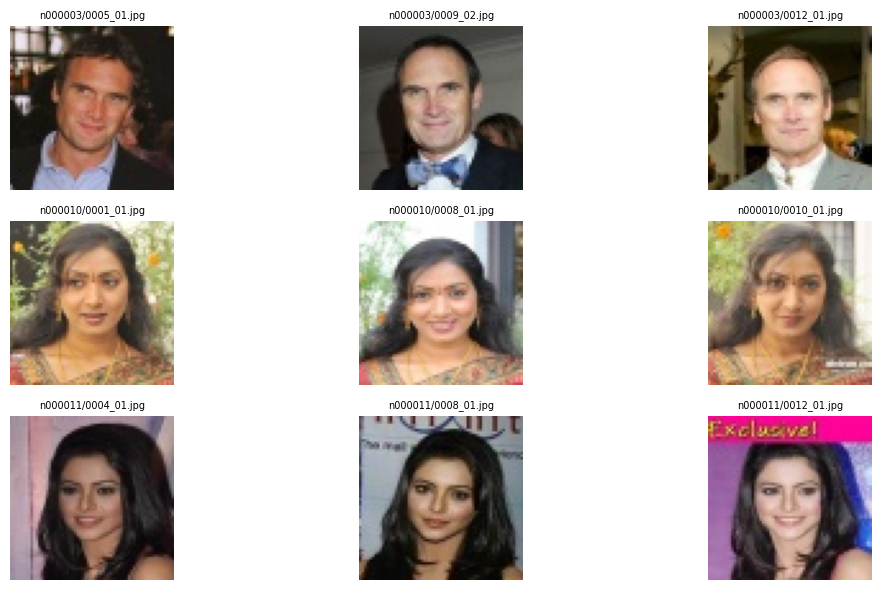

In [4]:
# Show 3 images of the first 3 people in train_data
first_three_folders = sorted(os.listdir(train_data))[:3]

plt.figure(figsize=(12, 6))
img_count = 1

for folder in first_three_folders:
    folder_path = os.path.join(train_data, folder)
    image_files = sorted(os.listdir(folder_path))[:3]  
    
    for image_file in image_files:
        img_path = os.path.join(folder_path, image_file)
        img = cv2.imread(img_path)
        if img is None:
            continue  # skip broken files
        img = img[..., ::-1]  # BGR → RGB
        
        plt.subplot(3, 3, img_count)
        plt.imshow(img)
        plt.title(f"{folder}/{image_file}", fontsize=7)
        plt.axis("off")
        img_count += 1

plt.tight_layout()
plt.show()

## 3) Custom callbacks

In [4]:
def cosine_annealing(epoch, lr_min, lr_max, max_epochs):
    return lr_min + 0.5 * (lr_max - lr_min) * (1 + np.cos(epoch / max_epochs * np.pi))

In [5]:
def custom_callback(
    model_name='model', 
    stop_monitor='val_accuracy', 
    save_dir='checkpoints',
    max_epochs=50,
    early_stopping=3,
    lr_min=1e-4,
    lr_max=1e-2
):
    # Ensure directory exists
    os.makedirs(save_dir, exist_ok=True)

    # Early stopping after 3 epochs without val_accuracy improvement
    early_stop = EarlyStopping(
        monitor=stop_monitor,
        patience=early_stopping,
        restore_best_weights=True
    )

    # Save the best model
    checkpoint = ModelCheckpoint(
        filepath=os.path.join(save_dir, f"{model_name}.keras"),
        monitor='val_accuracy',
        save_best_only=True
    )

    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)        

    def _schedule(epoch, current_lr):
        return cosine_annealing(
            epoch=epoch,
            lr_min=lr_min,
            lr_max=lr_max,
            max_epochs=max_epochs
        )
    
    lr_scheduler = LearningRateScheduler(_schedule)

    return [early_stop, checkpoint, reduce_lr, lr_scheduler]

## 4) Supervised learning (Classification based)

In [19]:
# Trade-off accuracy for speed
IMG_SIZE = 224
BATCH_SIZE = 32

In [20]:
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet_v2.preprocess_input,
    horizontal_flip=True,   
)

val_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet_v2.preprocess_input
)


train_generator = train_datagen.flow_from_directory(
    train_data,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse'  
)

validation_generator = val_datagen.flow_from_directory(
    val_data,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

Found 380638 images belonging to 4000 classes.
Found 8000 images belonging to 4000 classes.


### EfficientNetV2

**Feature extraction**

In [10]:
num_classes = train_generator.num_classes

# Load the base model
base_model = tf.keras.applications.EfficientNetV2B0(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze the base model
base_model.trainable = False 

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False) 
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = Dense(num_classes, activation='softmax')(x)


model = Model(inputs, outputs)

# Let's look at the structure
model.summary()

I0000 00:00:1763177946.775171      39 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1763177946.775876      39 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4000)           │       516,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,599,280 (25.17 MB)

 Trainable params: 679,968 (2.59 MB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [28]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
my_callbacks = custom_callback(
    model_name='effnetv2_head_training', 
    early_stopping=5,
    max_epochs=50
)

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50,
    steps_per_epoch=2000,
    validation_steps=250,
    callbacks=my_callbacks,
)

Epoch 1/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 341s 155ms/step - accuracy: 0.0062 - loss: 7.2332 - val_accuracy: 0.0094 - val_loss: 7.1104 - learning_rate: 0.0010
Epoch 2/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 245s 123ms/step - accuracy: 0.0083 - loss: 7.1416 - val_accuracy: 0.0099 - val_loss: 6.9869 - learning_rate: 0.0010
Epoch 3/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 245s 122ms/step - accuracy: 0.0088 - loss: 7.0666 - val_accuracy: 0.0117 - val_loss: 6.9097 - learning_rate: 0.0010
Epoch 4/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 228s 114ms/step - accuracy: 0.0101 - loss: 6.9977 - val_accuracy: 0.0148 - val_loss: 6.8058 - learning_rate: 0.0010
Epoch 5/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 210s 105ms/step - accuracy: 0.0110 - loss: 6.9719 - val_accuracy: 0.0164 - val_loss: 6.7784 - learning_rate: 0.0010
Epoch 6/50
1895/2000 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.0126 - loss: 6.9406

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


2000/2000 ━━━━━━━━━━━━━━━━━━━━ 184s 92ms/step - accuracy: 0.0126 - loss: 6.9403 - val_accuracy: 0.0178 - val_loss: 6.7555 - learning_rate: 0.0010
Epoch 7/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 198s 99ms/step - accuracy: 0.0127 - loss: 6.9157 - val_accuracy: 0.0161 - val_loss: 6.7008 - learning_rate: 0.0010
Epoch 8/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 162s 81ms/step - accuracy: 0.0122 - loss: 6.8740 - val_accuracy: 0.0162 - val_loss: 6.6509 - learning_rate: 0.0010
Epoch 9/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 140s 70ms/step - accuracy: 0.0133 - loss: 6.8625 - val_accuracy: 0.0175 - val_loss: 6.6491 - learning_rate: 0.0010
Epoch 10/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 137s 69ms/step - accuracy: 0.0133 - loss: 6.8572 - val_accuracy: 0.0184 - val_loss: 6.6163 - learning_rate: 0.0010
Epoch 11/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 142s 71ms/step - accuracy: 0.0148 - loss: 6.8486 - val_accuracy: 0.0215 - val_loss: 6.6132 - learning_rate: 0.0010
Epoch 12/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 118s 59ms/step - accurac

In [32]:
from IPython.display import FileLink

# This is the path where your ModelCheckpoint saved the file
file_path = 'checkpoints/effnetv2_head_training.keras'

# This creates a clickable link
FileLink(file_path)

/kaggle/working/checkpoints/effnetv2_head_training.keras

Fine-tuning

In [29]:
model_path = "/kaggle/input/effnetv2-head-training/keras/default/1/effnetv2_head_training.keras"
print(f"Loading model from {model_path}...")
effnet_model = tf.keras.models.load_model(model_path)
print("Model loaded successfully.")

effnet_model.summary()

Loading model from /kaggle/input/effnetv2-head-training/keras/default/1/effnetv2_head_training.keras...
Model loaded successfully.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4000)           │       516,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,959,222 (30.36 MB)

 Trainable params: 679,968 (2.59 MB)

 Non-trainable params: 5,919,312 (22.58 MB)

 Optimizer params: 1,359,942 (5.19 MB)

In [31]:
# Check the loaded model accuracy
print("Running sanity check on the loaded model...")

original_loss, original_acc = effnet_model.evaluate(
    validation_generator,
    steps=250,
    verbose=1
)

print(f"Loaded Model Stats - Loss: {original_loss:.4f}, Accuracy: {original_acc:.4f}")

Running sanity check on the loaded model...
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 50ms/step - accuracy: 0.0285 - loss: 6.4585
Loaded Model Stats - Loss: 6.4174, Accuracy: 0.0305


In [38]:
# Unfreeze the base EfficientNet V2 model
base_effnet = effnet_model.get_layer('efficientnetv2-b0')

base_effnet.trainable = True

# The number of layers to freeze
fine_tune_at = 190

for layer in base_effnet.layers[:fine_tune_at]:
    layer.trainable = False

# Keep BN layers frozen
for layer in base_effnet.layers[fine_tune_at:]:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

In [39]:
# Use a very small learning rate for fine-tuning
FINE_TUNE_LR = 1e-5 

effnet_model.compile(
    optimizer=Adam(learning_rate=FINE_TUNE_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

effnet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4000)           │       516,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,599,280 (25.17 MB)

 Trainable params: 3,748,368 (14.30 MB)

 Non-trainable params: 2,850,912 (10.88 MB)

In [40]:
# Fine-tune the model
my_callbacks = custom_callback(
    model_name='effnet_v2_finetune',
    max_epochs=50,
    early_stopping=5,
    lr_min=1e-6,
    lr_max=1e-5
)


history_fine_tune = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50,
    steps_per_epoch=2000,
    validation_steps=250,
    callbacks=my_callbacks,
)

Epoch 1/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 441s 220ms/step - accuracy: 0.0099 - loss: 7.4106 - val_accuracy: 0.0165 - val_loss: 6.7293 - learning_rate: 1.0000e-05
Epoch 2/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 383s 192ms/step - accuracy: 0.0117 - loss: 6.9954 - val_accuracy: 0.0207 - val_loss: 6.5750 - learning_rate: 9.9911e-06
Epoch 3/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 333s 166ms/step - accuracy: 0.0145 - loss: 6.8529 - val_accuracy: 0.0233 - val_loss: 6.4749 - learning_rate: 9.9645e-06
Epoch 4/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 300s 150ms/step - accuracy: 0.0166 - loss: 6.7695 - val_accuracy: 0.0264 - val_loss: 6.4212 - learning_rate: 9.9203e-06
Epoch 5/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 312s 156ms/step - accuracy: 0.0175 - loss: 6.7164 - val_accuracy: 0.0269 - val_loss: 6.3521 - learning_rate: 9.8586e-06
Epoch 6/50
1895/2000 ━━━━━━━━━━━━━━━━━━━━ 13s 128ms/step - accuracy: 0.0190 - loss: 6.6666

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


2000/2000 ━━━━━━━━━━━━━━━━━━━━ 263s 132ms/step - accuracy: 0.0190 - loss: 6.6655 - val_accuracy: 0.0302 - val_loss: 6.3189 - learning_rate: 9.7798e-06
Epoch 7/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 256s 128ms/step - accuracy: 0.0202 - loss: 6.6071 - val_accuracy: 0.0318 - val_loss: 6.2916 - learning_rate: 9.6840e-06
Epoch 8/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 245s 122ms/step - accuracy: 0.0215 - loss: 6.5721 - val_accuracy: 0.0324 - val_loss: 6.2564 - learning_rate: 9.5717e-06
Epoch 9/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 236s 118ms/step - accuracy: 0.0230 - loss: 6.5357 - val_accuracy: 0.0327 - val_loss: 6.2401 - learning_rate: 9.4434e-06
Epoch 10/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 218s 109ms/step - accuracy: 0.0218 - loss: 6.5298 - val_accuracy: 0.0340 - val_loss: 6.2077 - learning_rate: 9.2995e-06
Epoch 11/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 197s 99ms/step - accuracy: 0.0224 - loss: 6.5128 - val_accuracy: 0.0336 - val_loss: 6.1805 - learning_rate: 9.1406e-06
Epoch 12/50
2000/2000 ━━━━━━━━━━━━━━━━

**Training history**

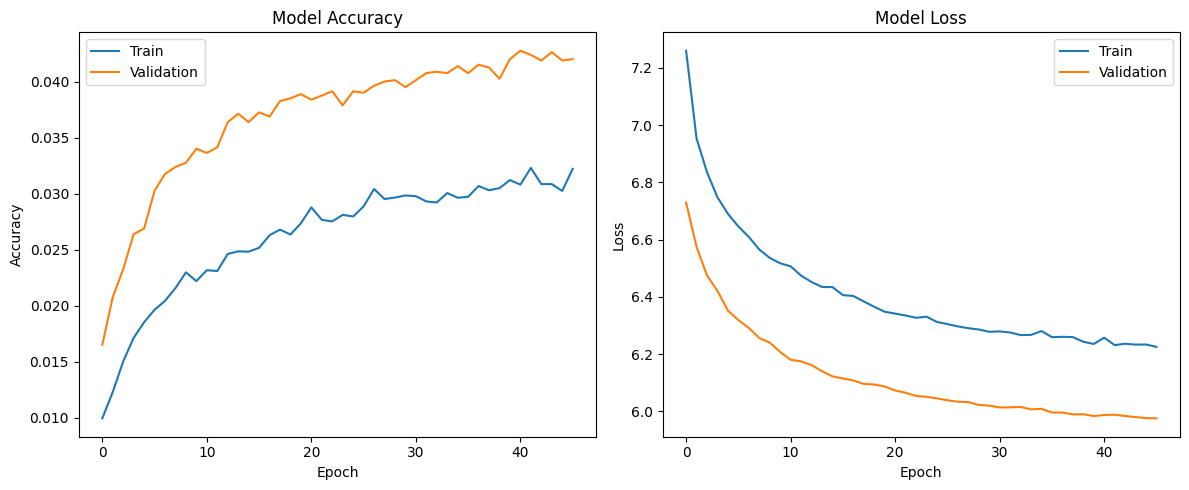

In [43]:
import matplotlib.pyplot as plt

# --- Summarize history for accuracy ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_fine_tune.history['accuracy'])
plt.plot(history_fine_tune.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# --- Summarize history for loss ---
plt.subplot(1, 2, 2)
plt.plot(history_fine_tune.history['loss'])
plt.plot(history_fine_tune.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

plt.tight_layout()
plt.show()

In [45]:
from IPython.display import FileLink

# This is the path where your ModelCheckpoint saved the file
file_path = 'checkpoints/effnet_v2_finetune.keras'

# This creates a clickable link
FileLink(file_path)

/kaggle/working/checkpoints/effnet_v2_finetune.keras

## Metric learning (Siamese network)

### Build the base ResNet50 for embedding

In [10]:
# Build the embedding model
from tensorflow.keras.applications import resnet

inputs = keras.Input((224, 224) + (3,))
x = resnet.preprocess_input(inputs)

# fetch the pre-trained resnet 50 model and freeze the weights
base_resnet = resnet.ResNet50(weights="imagenet", include_top=False)
base_resnet.trainable=False

extractedFeatures = base_resnet(x)
x = layers.GlobalAveragePooling2D()(extractedFeatures)
x = layers.Dense(units=512, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(units=128)(x)

# build the embedding model and return it
embedding_model = keras.Model(inputs, outputs, name="embedding")

I0000 00:00:1763551657.438048      39 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1763551657.438719      39 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


### Build the Siamese Network

In [11]:
# Build the anchor, positive and negative input layer
anchorInput = keras.Input(name="anchor", shape=(224, 224) + (3,))
positiveInput = keras.Input(name="positive", shape=(224,224) + (3,))
negativeInput = keras.Input(name="negative", shape=(224,224) + (3,))

# Embed the anchor, positive and negative images
anchorEmbedding = embedding_model(anchorInput)
positiveEmbedding = embedding_model(positiveInput)
negativeEmbedding = embedding_model(negativeInput)

# Build the Siamese network
siamese_network = keras.Model(
    inputs=[anchorInput, positiveInput, negativeInput],
    outputs=[anchorEmbedding, positiveEmbedding, negativeEmbedding]
)

### Build the Model wrapper to train the Siamese Network

In [12]:
# Helper function to calculate L2 distance
def l2_distance(y_true, y_pred):
    # Sum of squared differences
    sum_squared = tf.reduce_sum(tf.square(y_true - y_pred), axis=1, keepdims=True)
    # Square root of the sum
    return tf.sqrt(tf.maximum(sum_squared, tf.keras.backend.epsilon()))

# Helper function for the triplet loss
def triplet_loss(anchor_emb, positive_emb, negative_emb, margin):
    d_ap = l2_distance(anchor_emb, positive_emb)
    d_an = l2_distance(anchor_emb, negative_emb)
    
    # Calculate the loss
    # max(d(A,P) - d(A,N) + margin, 0)
    loss = d_ap - d_an + margin
    loss = tf.maximum(loss, 0.0)
    
    return tf.reduce_mean(loss)

In [13]:
class SiameseModel(keras.Model):
    def __init__(self, siamese_network, margin=0.5):
        super().__init__()
        self.siamese_network = siamese_network
        self.margin = margin
        self.loss_tracker = keras.metrics.Mean(name="loss")

    def compile(self, optimizer, **kwargs):
        super().compile(**kwargs)
        self.optimizer = optimizer

    # Custom training logic
    def train_step(self, data):
        anchor, positive, negative = data

        with tf.GradientTape() as tape:
            # Get the embeddings from the siamese network
            anchor_emb, positive_emb, negative_emb = self.siamese_network(
                [anchor, positive, negative], training=True
            )
            
            # Calculate the custom triplet loss
            loss = triplet_loss(anchor_emb, positive_emb, negative_emb, self.margin)
            
        # Calculate gradients
        gradients = tape.gradient(loss, self.siamese_network.trainable_variables)
        
        # Apply gradients to update the weights
        self.optimizer.apply_gradients(
            zip(gradients, self.siamese_network.trainable_variables)
        )
        
        # Update our loss tracker
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    # Add a custom test_step to monitor validation
    def test_step(self, data):
        anchor, positive, negative = data
        
        anchor_emb, positive_emb, negative_emb = self.siamese_network(
            [anchor, positive, negative], training=False
        )
        
        loss = triplet_loss(anchor_emb, positive_emb, negative_emb, self.margin)
        
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    @property
    def metrics(self):
        return [self.loss_tracker]

In [14]:
siamese_model = SiameseModel(siamese_network, margin=0.5)

siamese_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3)
)

### Create the data pipeline

In [16]:
class_names = sorted(os.listdir(train_data))
image_dict = {}

for class_name in class_names:
    class_path = os.path.join(train_data, class_name)
    if os.path.isdir(class_path):
        # List all images in this person's folder
        images = [os.path.join(class_path, img) for img in os.listdir(class_path) 
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        if len(images) > 1:
            image_dict[class_name] = images

print(f"Found {len(image_dict)} classes with at least 2 images.")
class_list = list(image_dict.keys())

Found 4000 classes with at least 2 images.


In [17]:
def triplet_generator():
    while True:
        # Pick a random person for the Anchor/Positive
        anchor_person = random.choice(class_list)
        
        # Pick a DIFFERENT random person for the Negative
        negative_person = random.choice(class_list)
        while negative_person == anchor_person:
            negative_person = random.choice(class_list)

        # Anchor and Positive come from anchor_person
        anchor_img_path = random.choice(image_dict[anchor_person])
        positive_img_path = random.choice(image_dict[anchor_person])
        
        # Make sure Anchor and Positive are different images
        while positive_img_path == anchor_img_path:
            positive_img_path = random.choice(image_dict[anchor_person])
            
        # Negative comes from negative_person
        negative_img_path = random.choice(image_dict[negative_person])

        yield (anchor_img_path, positive_img_path, negative_img_path)

In [19]:
IMG_SIZE = 224
BATCH_SIZE = 32

# Load and resize images
def preprocess_triplets(anchor_path, positive_path, negative_path):
    def load_image(path):
        img_raw = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img_raw, channels=3)
        img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
        img = tf.keras.applications.resnet50.preprocess_input(img) # Use ResNet preprocessing!
        return img

    return (load_image(anchor_path), load_image(positive_path), load_image(negative_path))

# Create the dataset from the generator
triplet_dataset = tf.data.Dataset.from_generator(
    triplet_generator,
    output_signature=(
        tf.TensorSpec(shape=(), dtype=tf.string),
        tf.TensorSpec(shape=(), dtype=tf.string),
        tf.TensorSpec(shape=(), dtype=tf.string)
    )
)

# Map the loading function and batch the data
triplet_dataset = (
    triplet_dataset
    .map(preprocess_triplets, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Triplet dataset pipeline ready.")

Triplet dataset pipeline ready.


In [20]:
EPOCHS = 20
STEPS_PER_EPOCH = 1000

history = siamese_model.fit(
    triplet_dataset,
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH
)

Epoch 1/20


I0000 00:00:1763551856.787418     106 service.cc:148] XLA service 0x7a86400026b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763551856.788440     106 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1763551856.788478     106 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1763551861.387221     106 cuda_dnn.cc:529] Loaded cuDNN version 90300


   2/1000 ━━━━━━━━━━━━━━━━━━━━ 1:28 89ms/step - loss: 0.9937   

I0000 00:00:1763551869.585577     106 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 232s 193ms/step - loss: 0.7403
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 205s 205ms/step - loss: 0.4546
Epoch 3/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 171s 171ms/step - loss: 0.3642
Epoch 4/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 150s 150ms/step - loss: 0.3118
Epoch 5/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 117s 117ms/step - loss: 0.2947
Epoch 6/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 112s 112ms/step - loss: 0.2688
Epoch 7/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 113s 113ms/step - loss: 0.2577
Epoch 8/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 116s 116ms/step - loss: 0.2401
Epoch 9/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 112s 112ms/step - loss: 0.2261
Epoch 10/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 110s 110ms/step - loss: 0.2158
Epoch 11/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 106s 106ms/step - loss: 0.2108
Epoch 12/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 103s 103ms/step - loss: 0.2072
Epoch 13/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 101s 101ms/step - loss: 0.2084
Epoch 14/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 101s 101ms/step

In [26]:
from IPython.display import FileLink

save_name = 'final_face_embedding_model.keras'
embedding_model.save(save_name)
print(f"Model saved as {save_name}")

FileLink(save_name)

Model saved as final_face_embedding_model.keras


/kaggle/working/final_face_embedding_model.keras

## Evaluation

Loading pairs from: /kaggle/input/11-785-fall-20-homework-2-part-2/verification_pairs_val.txt
Found 8805 verification pairs.
276/276 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step
276/276 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step

 Final AUC Score: 0.8077
Optimal Distance Threshold: 2.3613


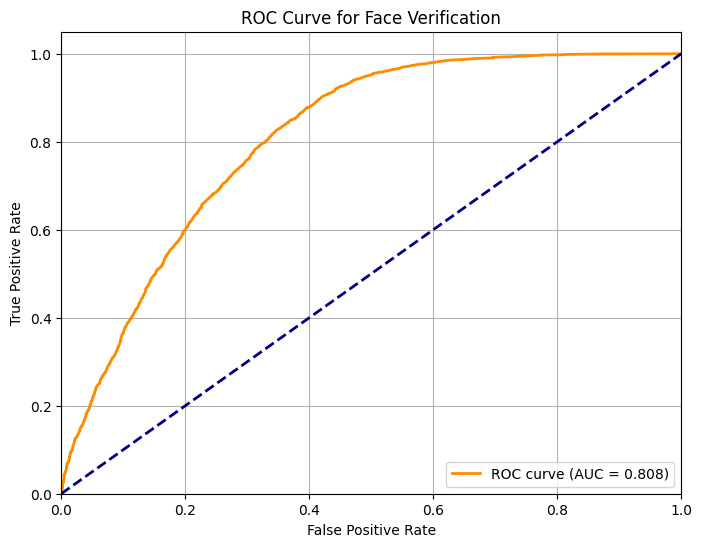

In [25]:
dataset_root = base_path 
IMG_SIZE = 224

def preprocess_image(filename):
    """Loads and preprocesses a single image."""
    # FIX: Join with the ROOT path, not the verification subfolder
    file_path = tf.strings.join([dataset_root, os.sep, filename])
    
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    
    # Apply ResNet preprocessing
    img = tf.keras.applications.resnet50.preprocess_input(img)
    return img

def load_pairs(filepath):
    """Reads the text file to get image names and labels."""
    pairs = []
    labels = []
    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 3:
                # These parts likely look like "verification_data/0001.jpg"
                pairs.append((parts[0], parts[1]))
                labels.append(int(parts[2]))
    return pairs, np.array(labels)

# Generate Embeddings ---
print(f"Loading pairs from: {verification_pairs_val}")
pairs, labels = load_pairs(verification_pairs_val)
print(f"Found {len(pairs)} verification pairs.")

img1_paths = [p[0] for p in pairs]
img2_paths = [p[1] for p in pairs]

def create_dataset(file_paths):
    ds = tf.data.Dataset.from_tensor_slices(file_paths)
    ds = ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(32)
    return ds

embeddings1 = embedding_model.predict(create_dataset(img1_paths), verbose=1)

embeddings2 = embedding_model.predict(create_dataset(img2_paths), verbose=1)

# Calculate Distances & Metrics
distances = np.sqrt(np.sum(np.square(embeddings1 - embeddings2), axis=1))

# Invert distance for score (Lower distance = Higher similarity)
scores = -distances 

fpr, tpr, thresholds = roc_curve(labels, scores)
roc_auc = auc(fpr, tpr)

print(f"\n Final AUC Score: {roc_auc:.4f}")

# Find Optimal Threshold 
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = -thresholds[optimal_idx]

print(f"Optimal Distance Threshold: {optimal_threshold:.4f}")

# Plot ROC Curve ---
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Face Verification')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [33]:
model_path = "/kaggle/input/effnet-v2-fine-tune/keras/default/1/effnet_v2_finetune.keras"
print(f"Loading model from {model_path}...")
effnet_model = tf.keras.models.load_model(model_path)
print("Model loaded successfully.")

effnet_model.summary()

Loading model from /kaggle/input/effnet-v2-fine-tune/keras/default/1/effnet_v2_finetune.keras...
Model loaded successfully.


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 86 variables whereas the saved optimizer has 170 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 82 variables whereas the saved optimizer has 166 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4000)           │       516,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,096,022 (53.77 MB)

 Trainable params: 3,748,368 (14.30 MB)

 Non-trainable params: 2,850,912 (10.88 MB)

 Optimizer params: 7,496,742 (28.60 MB)

In [34]:
# Check the loaded model accuracy
print("Running sanity check on the loaded model...")

original_loss, original_acc = effnet_model.evaluate(
    validation_generator,
    steps=250,
    verbose=1
)

print(f"Loaded Model Stats - Loss: {original_loss:.4f}, Accuracy: {original_acc:.4f}")

Running sanity check on the loaded model...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


250/250 ━━━━━━━━━━━━━━━━━━━━ 80s 274ms/step - accuracy: 0.0413 - loss: 6.0209
Loaded Model Stats - Loss: 5.9875, Accuracy: 0.0425


In [35]:
# Remove the softmax layer
new_output = effnet_model.layers[-3].output

effnet_embedding = tf.keras.Model(inputs=effnet_model.input, outputs=new_output)

print("New Model Summary:")
effnet_embedding.summary()

New Model Summary:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,083,280 (23.21 MB)

 Trainable params: 3,232,368 (12.33 MB)

 Non-trainable params: 2,850,912 (10.88 MB)

Loading pairs from: /kaggle/input/11-785-fall-20-homework-2-part-2/verification_pairs_val.txt
Found 8805 verification pairs.
276/276 ━━━━━━━━━━━━━━━━━━━━ 25s 65ms/step
276/276 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step

 Final AUC Score: 0.5017
Optimal Distance Threshold: 4.7344


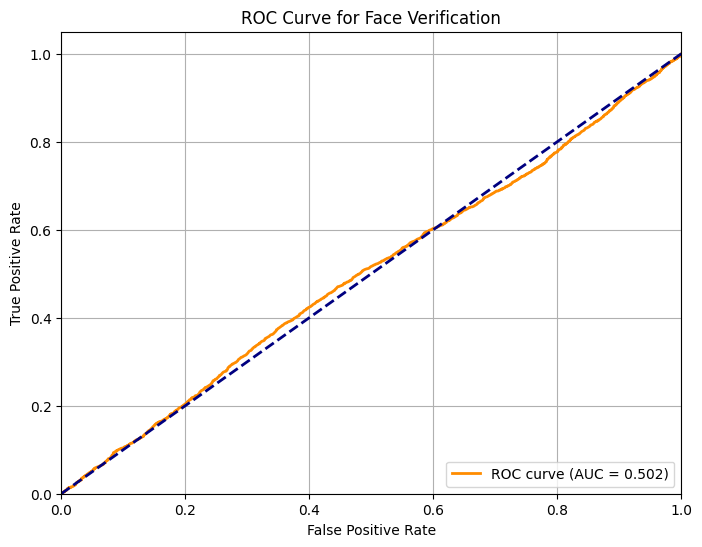

In [36]:
dataset_root = base_path 
IMG_SIZE = 224

def preprocess_image(filename):
    """Loads and preprocesses a single image."""
    # FIX: Join with the ROOT path, not the verification subfolder
    file_path = tf.strings.join([dataset_root, os.sep, filename])
    
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    
    # Apply ResNet preprocessing
    img = tf.keras.applications.resnet50.preprocess_input(img)
    return img

def load_pairs(filepath):
    """Reads the text file to get image names and labels."""
    pairs = []
    labels = []
    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 3:
                # These parts likely look like "verification_data/0001.jpg"
                pairs.append((parts[0], parts[1]))
                labels.append(int(parts[2]))
    return pairs, np.array(labels)

# Generate Embeddings ---
print(f"Loading pairs from: {verification_pairs_val}")
pairs, labels = load_pairs(verification_pairs_val)
print(f"Found {len(pairs)} verification pairs.")

img1_paths = [p[0] for p in pairs]
img2_paths = [p[1] for p in pairs]

def create_dataset(file_paths):
    ds = tf.data.Dataset.from_tensor_slices(file_paths)
    ds = ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(32)
    return ds

embeddings1 = effnet_embedding.predict(create_dataset(img1_paths), verbose=1)

embeddings2 = effnet_embedding.predict(create_dataset(img2_paths), verbose=1)

# Calculate Distances & Metrics
distances = np.sqrt(np.sum(np.square(embeddings1 - embeddings2), axis=1))

# Invert distance for score (Lower distance = Higher similarity)
scores = -distances 

fpr, tpr, thresholds = roc_curve(labels, scores)
roc_auc = auc(fpr, tpr)

print(f"\n Final AUC Score: {roc_auc:.4f}")

# Find Optimal Threshold 
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = -thresholds[optimal_idx]

print(f"Optimal Distance Threshold: {optimal_threshold:.4f}")

# Plot ROC Curve ---
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Face Verification')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()